In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage import data

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals, visualize_flattened_images
from python_utils.ml_utils import min_max_normalize
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN
from bss.PredictiveDecorrBSS import PredictiveDecorrBSS

# Generate Sources and Mix Them (10 by 5 case)

/nfs/ghome/live/bbozkurt/.conda/envs/predictivebss2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(512, 512) (512, 512) (512, 512)


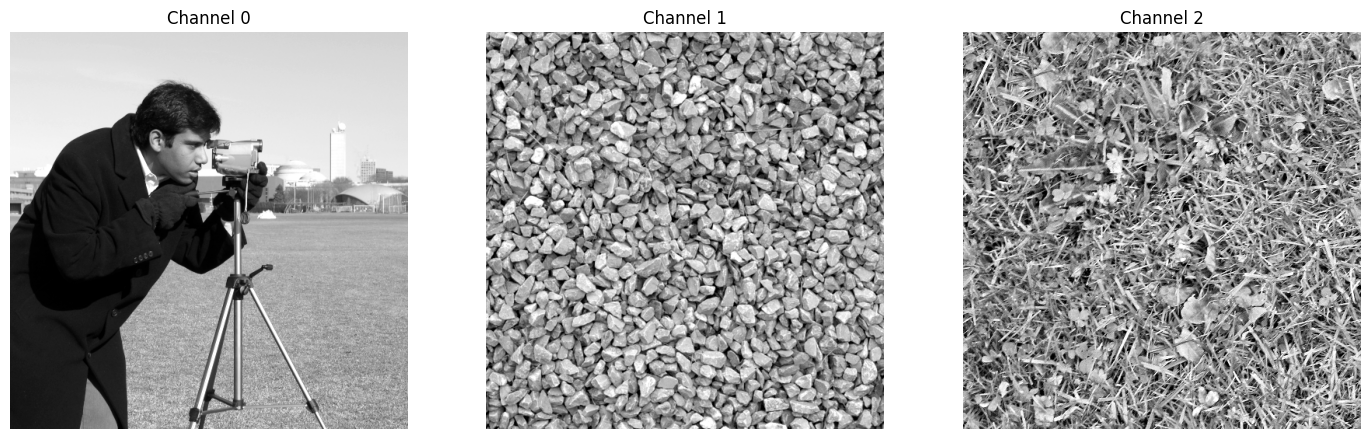

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 40.00800291682151


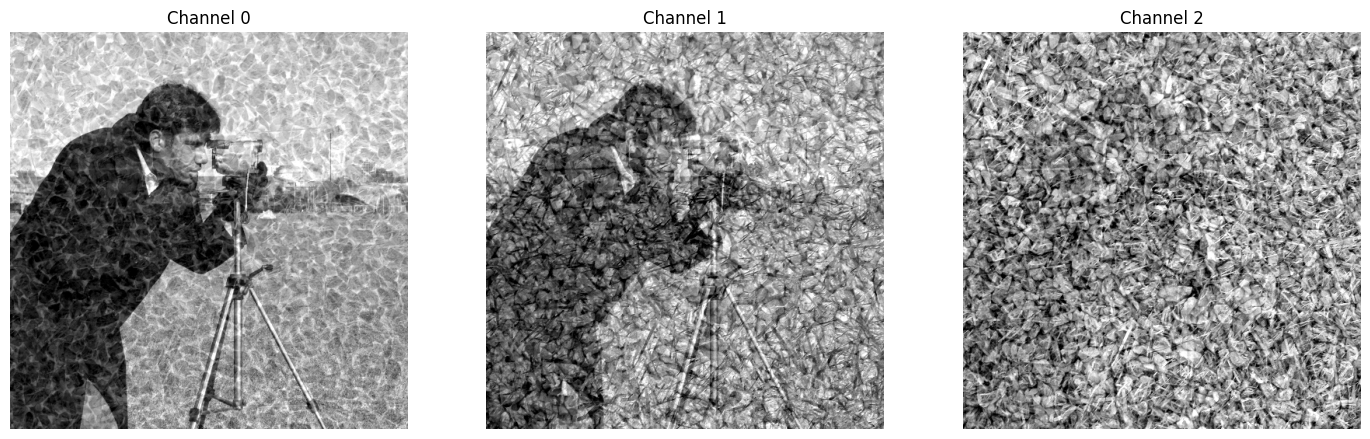

In [2]:
seed = 1250
np.random.seed(seed)
# 1. Load and normalize sources to [0, 1] for Simplex/NN-Antisparse domains
s1 = data.camera().astype(float) / 255.0
s2 = data.gravel().astype(float) / 255.0
s3 = data.grass().astype(float) / 255.0

# s3 = data.coins().astype(float) / 255.0
# s3 = data.text().astype(float) / 255.0

print(s1.shape, s2.shape, s3.shape)
# Ensure they are the same size (cropping to the smallest common dimensions)
h, w = 512, 512 
S_raw = np.stack([s1[:h, :w], s2[:h, :w], s3[:h, :w]], axis=0) # Shape: (3, 512, 512)
NumberofSources = S_raw.shape[0]
n_pixels = h * w

# Flatten for the BSS model: (n_sources, T)
S = S_raw.reshape(NumberofSources, n_pixels)
S = min_max_normalize(S, axis = 1)
visualize_flattened_images(S, imsize=(h, w))

NumberofMixtures = 3
# # Generate Mxr random mixing from i.i.d N(0,1)
# A = - np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = np.random.uniform(0.3, 0.7, (NumberofMixtures, NumberofSources))
A = -ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 40
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

visualize_flattened_images(X, imsize=(h, w))

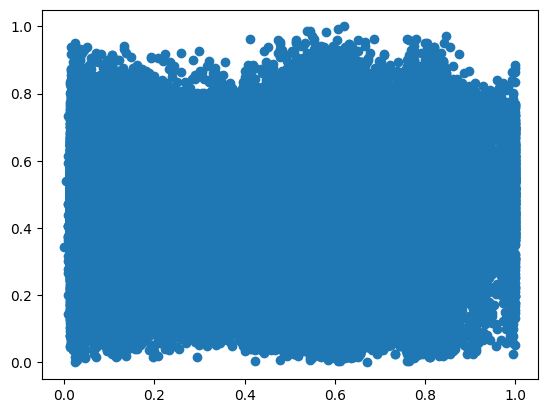

In [3]:
plt.scatter(S[0, :], S[2, :])

In [4]:
np.corrcoef(S)

array([[ 1.        , -0.02068012,  0.05767175],
       [-0.02068012,  1.        , -0.00584025],
       [ 0.05767175, -0.00584025,  1.        ]])

# Hyperparameters

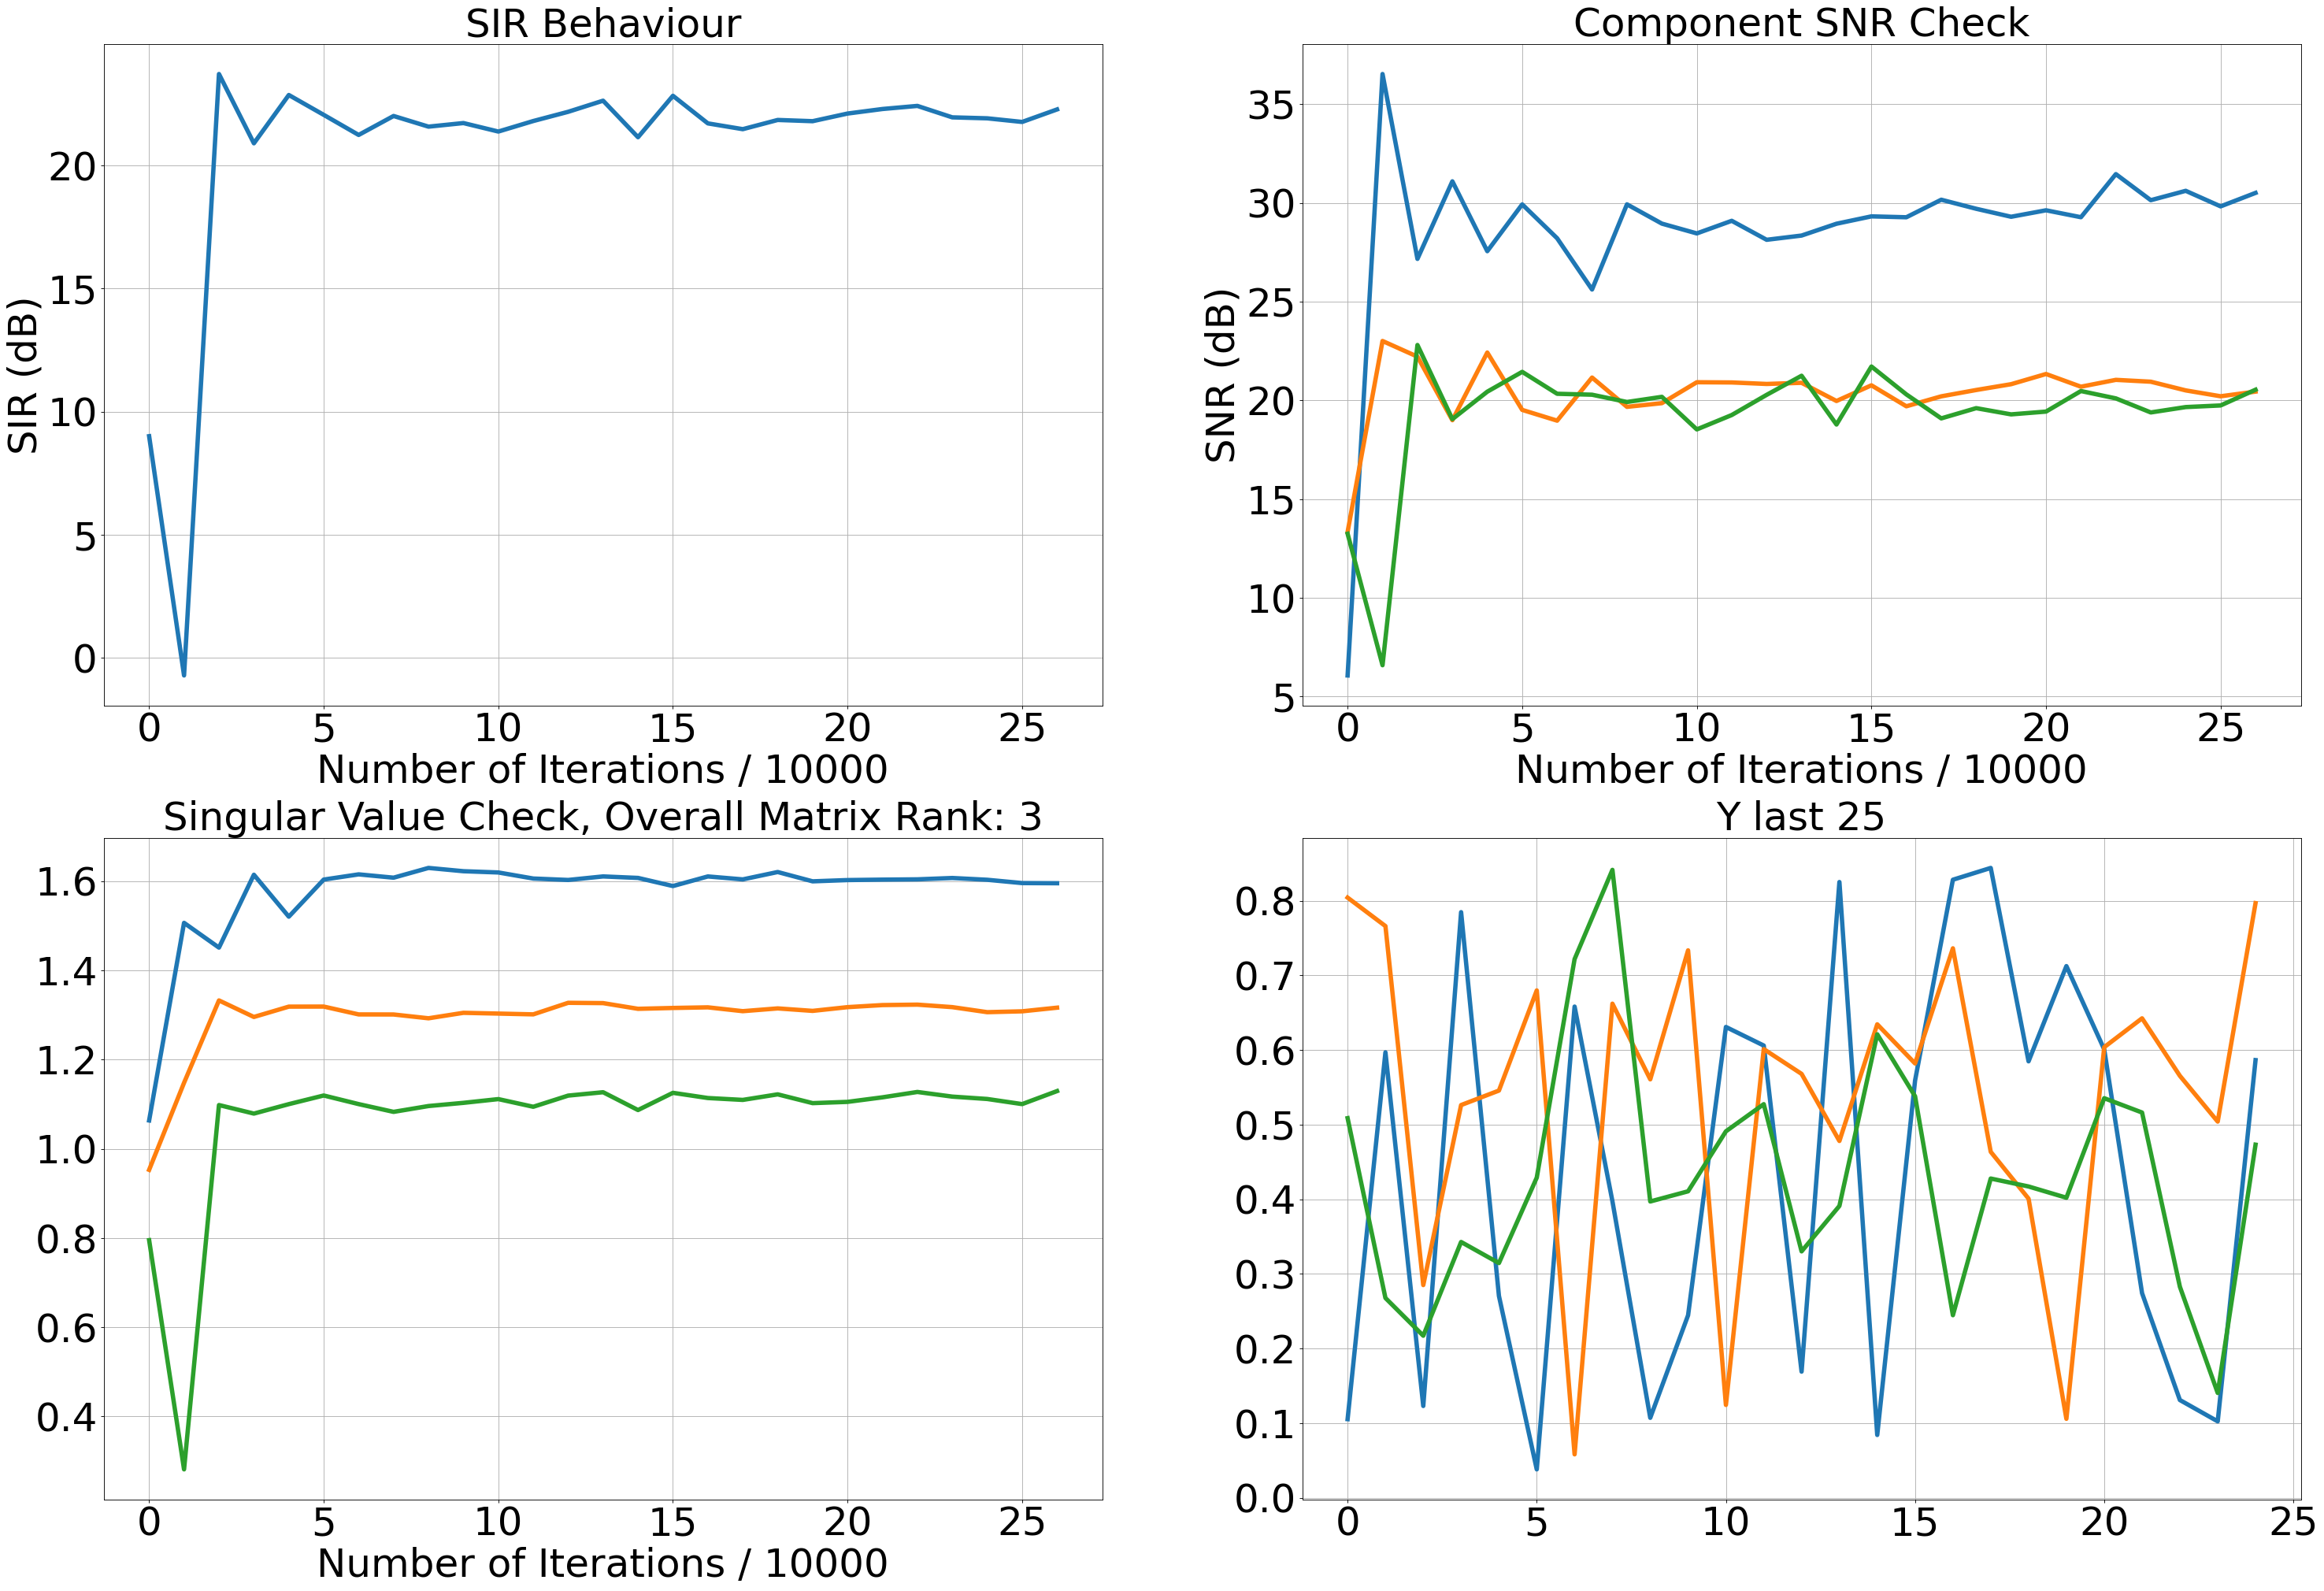

100%|██████████████████████████████████████████████████████████████████████████████████████████| 262144/262144 [01:04<00:00, 4075.45it/s]


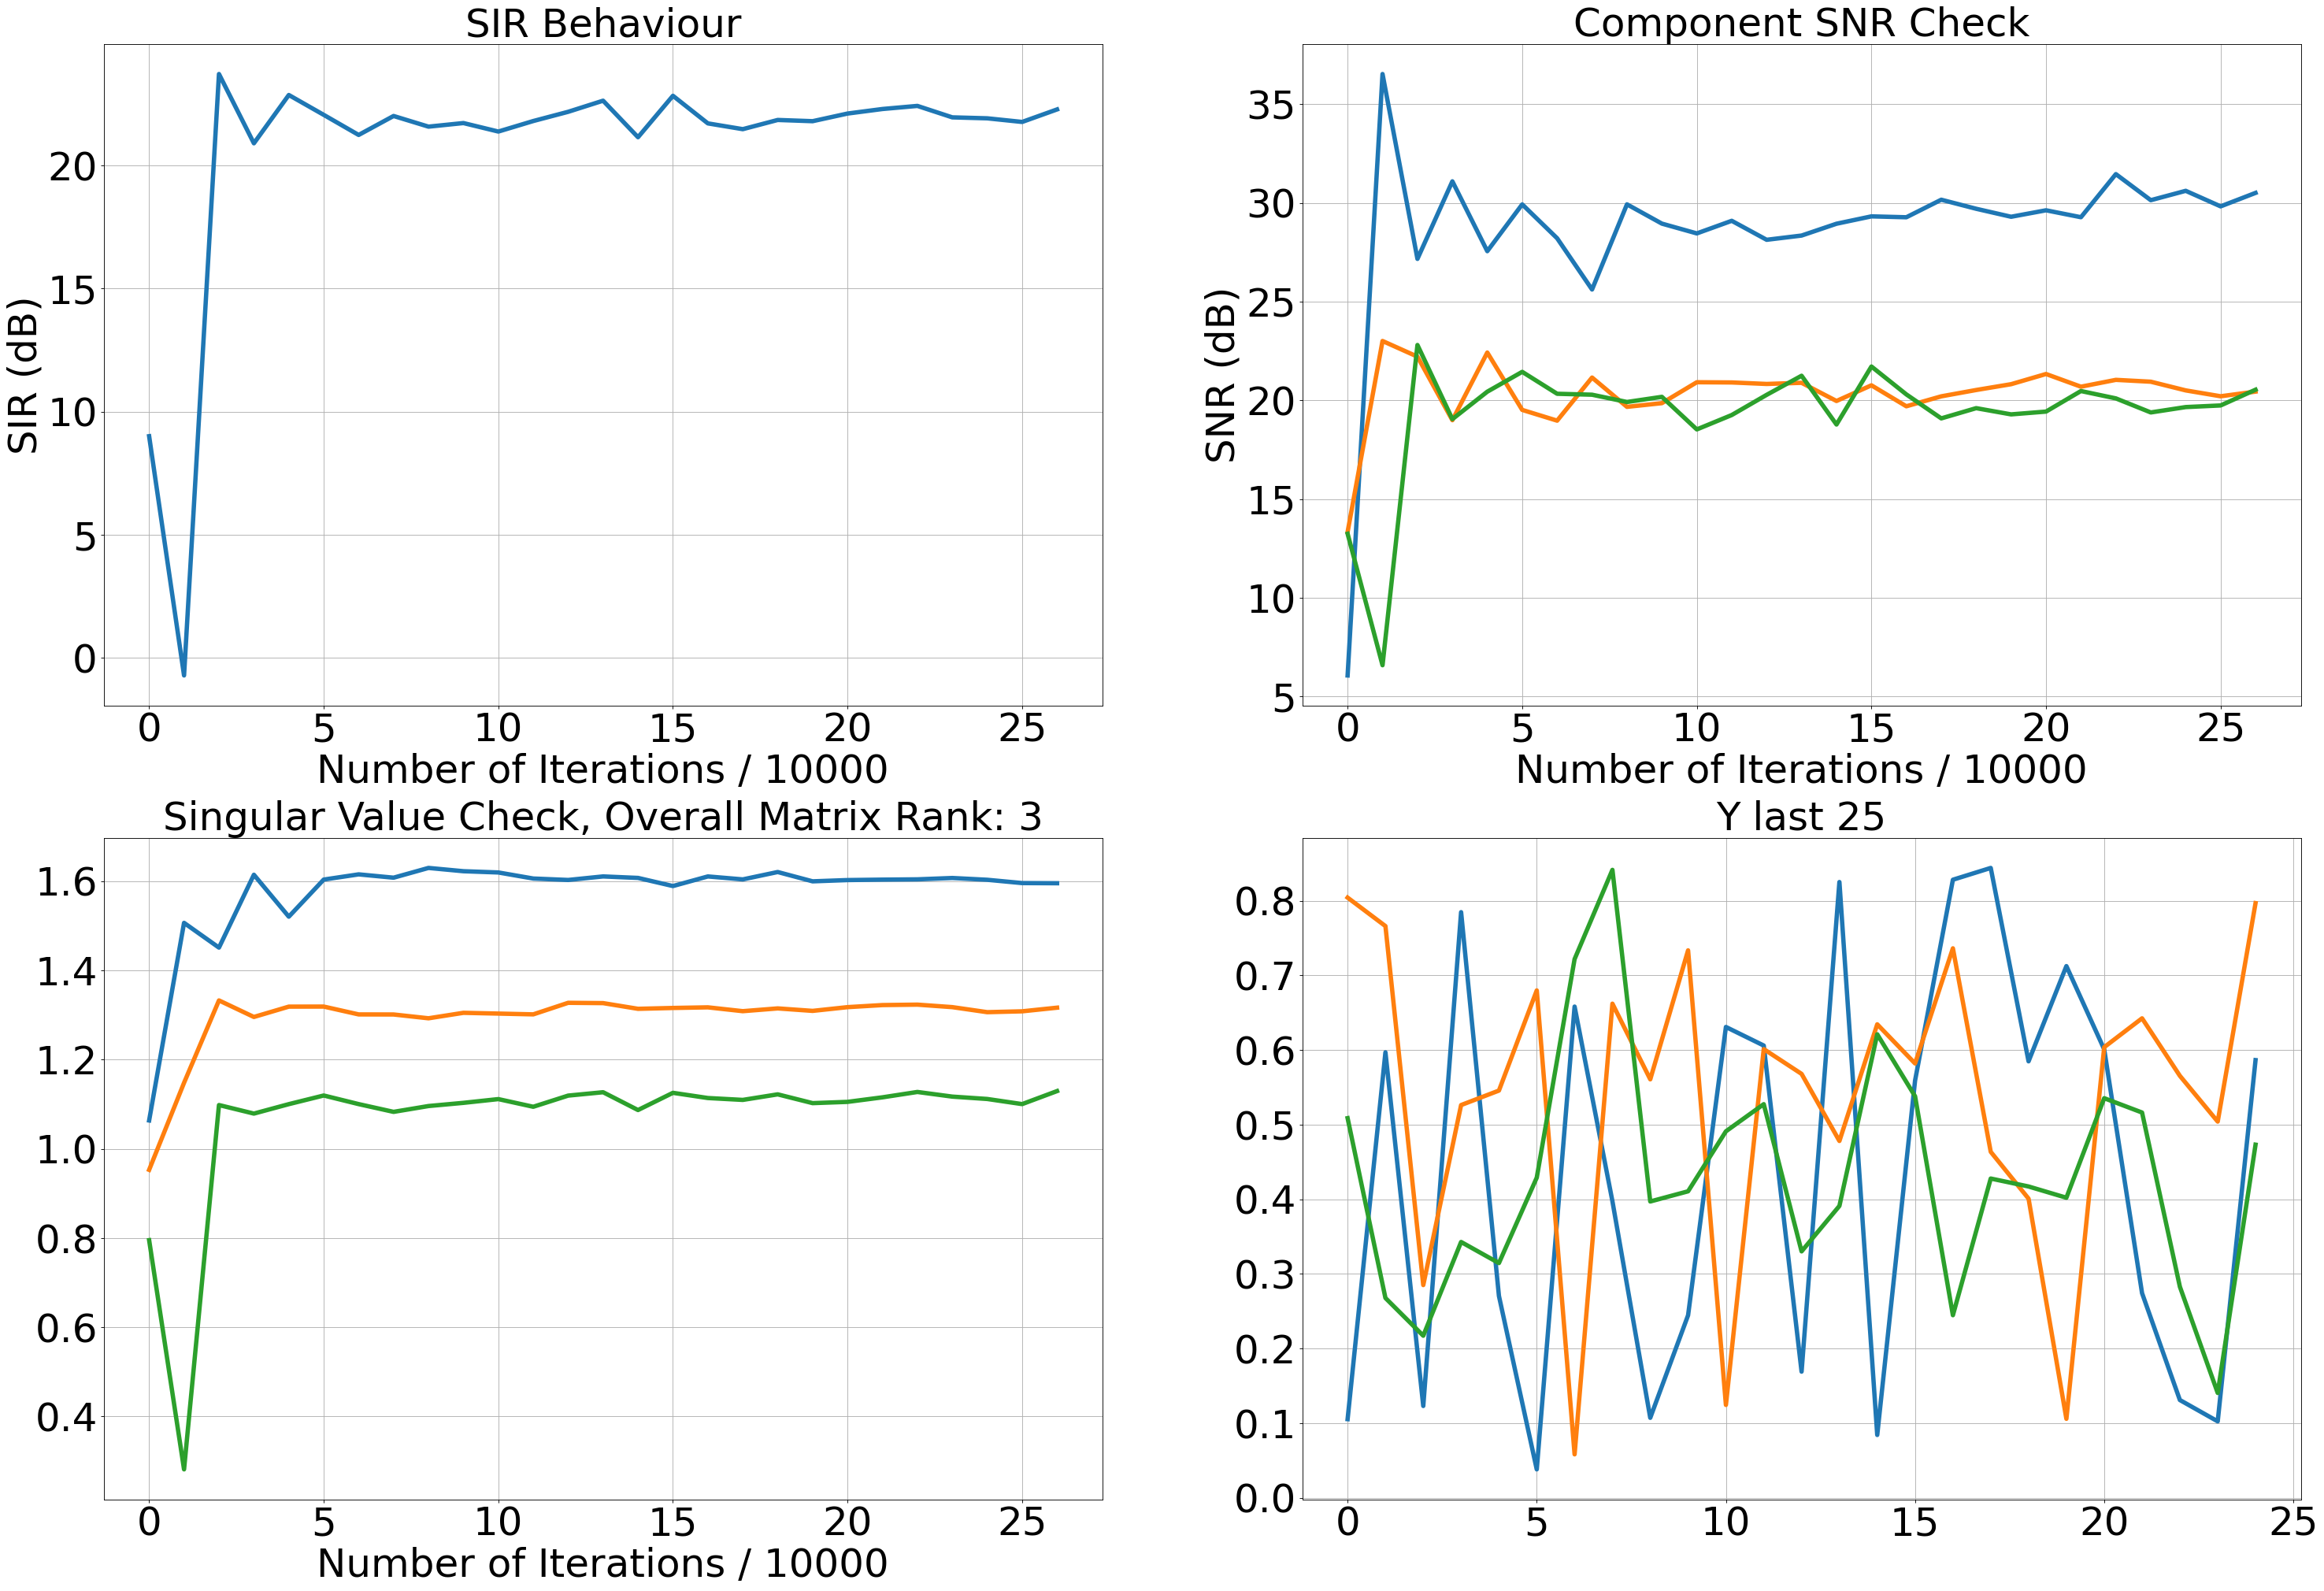

In [5]:
np.random.seed(seed)
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "nnantisparse",
                ### Optimization parameters
                "lambda_lateral" : 0.99,
                "gamma_predictive" : 750,
                ### Learning rates 
                "lr_W" : 15 * 1e-1,
                "neural_lr_start" : 0.1,
                "neural_lr_stop" : 1e-6,
                "neural_dynamics_iterations" : 250,
                "neural_OUTPUT_COMP_TOL" : 1e-6,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "divide_by_index",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrBSS(**hyperparam_dict)
# model.C_y = np.eye(NumberofSources) / 1 + np.random.randn(NumberofSources, NumberofSources) / 15
model.W = np.random.randn(NumberofSources, NumberofMixtures) / 10 + np.eye(NumberofSources, NumberofMixtures) 
model.mu_y = 0.5 * np.ones(NumberofSources)
model.fit(X, shuffle_samples = True)

In [6]:
display_matrix(model.C_y)

<IPython.core.display.Math object>

In [7]:
display_matrix(model.mu_y.reshape(1, -1))

<IPython.core.display.Math object>

In [8]:
display_matrix(model.W)

<IPython.core.display.Math object>

In [9]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(S, Y_)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 22.13301005985743
Component Signal-to-Noise-Ratio (SNR) Values : [29.7869073  20.43301654 20.34966961]



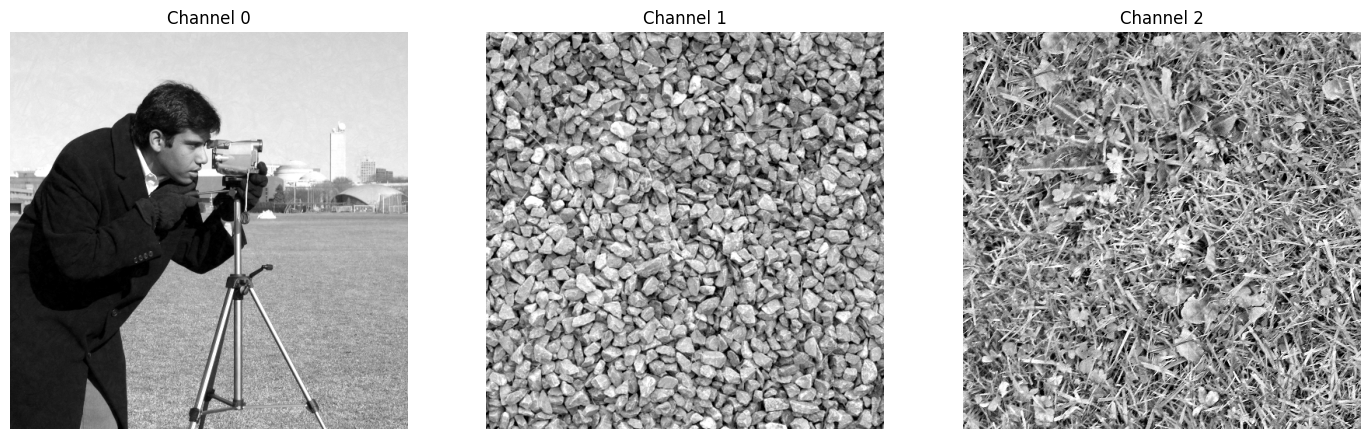

In [10]:
visualize_flattened_images(Y_, imsize=(h, w))

# Plot for Publication

In [11]:
def plot_image_separation_results(S_gt, X_mix, Y_rec, titles=None, save_path = None):
    """
    S_gt: Ground truth sources (n_sources, h, w)
    X_mix: Selected mixtures (e.g., first 3) (n_mixtures, h, w)
    Y_rec: Recovered sources (n_sources, h, w)
    """
    n_sources = S_gt.shape[0]
    fig, axes = plt.subplots(3, n_sources, figsize=(n_sources * 3, 10))
    
    rows = ['Ground Truth', 'Mixtures (Samples)', 'Recovered']
    
    for row_idx, data in enumerate([S_gt, X_mix[:n_sources], Y_rec]):
        for col_idx in range(n_sources):
            ax = axes[row_idx, col_idx]
            # Normalize for display
            img = data[col_idx]
            v_min, v_max = np.percentile(img, [1, 99])
            ax.imshow(img, cmap='gray', vmin=v_min, vmax=v_max)
            ax.set_xticks([])
            ax.set_yticks([])
            
            if col_idx == 0:
                ax.set_ylabel(rows[row_idx], fontsize=14, fontweight='bold')
            if row_idx == 0 and titles:
                ax.set_title(titles[col_idx], fontsize=12)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format='pdf', bbox_inches = 'tight')
    plt.show()

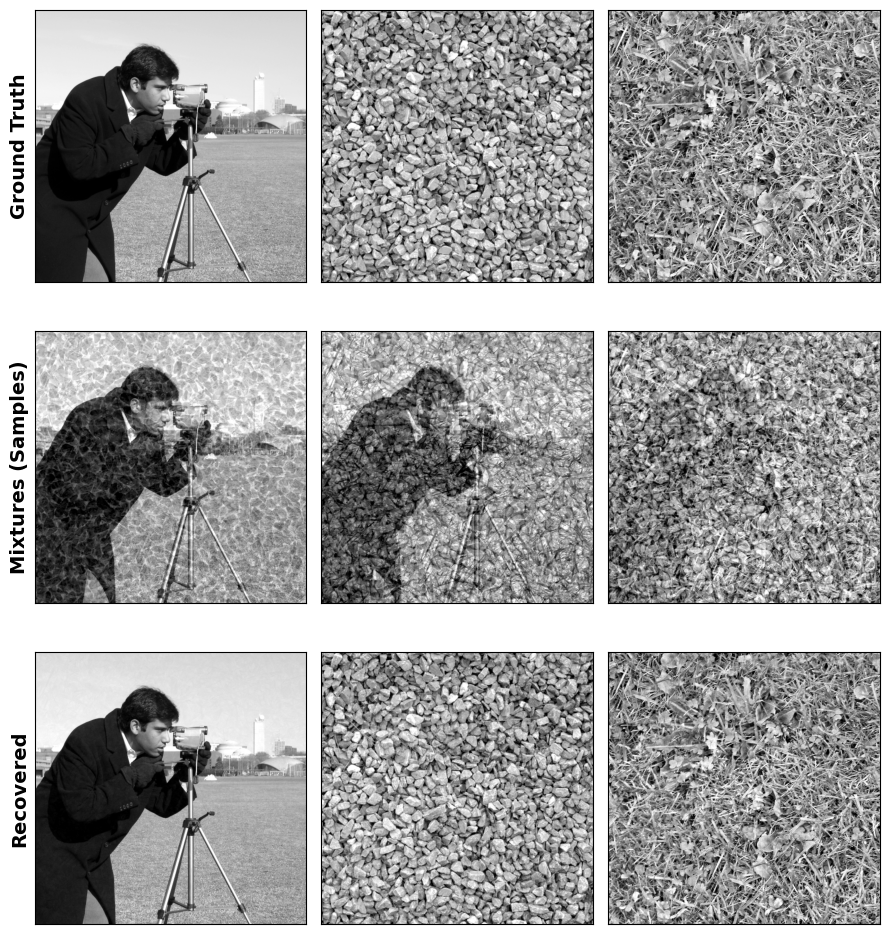

In [12]:
save_path = '../AnalyzeSimulationResults/Figures/Image_Separation_Comparison.pdf'
plot_image_separation_results(S.reshape(3, h, w), X.reshape(3, h, w), model.predict(X).reshape(3, h, w), save_path = save_path)